# TextBench : classification du genre d'un livre à partir de son résumé

Mini-projet NLP. Nous comparons trois approches sur **les mêmes données et avec le même protocole** :

- une baseline sans apprentissage (règles et lexique) ;
- un modèle PyTorch entraîné par nos soins (TF-IDF + MLP) ;
- un Transformer pré-entraîné et affiné (DistilBERT).

| Membre | Rôle | Code |
| --- | --- | --- |
| Elyes | Données et protocole | `notebooks/cleaning.ipynb`, `notebooks/spliting.ipynb` |
| Clément | Baseline sans ML | `src/baseline.py` |
| Faiki | Deep Learning PyTorch | `src/deep_learning.py` |
| Nathan | Transformer | `src/transformer.py` |
| Arno | Évaluation et analyse | `src/evaluation.py`, `src/run_evaluation.py`, `src/analysis.py` |

**Exécution** : `uv run jupyter nbconvert --to notebook --execute --inplace notebooks/projet.ipynb`
(environ 1 minute avec les drapeaux par défaut). Le notebook importe les modules de `src/` et
recharge les artefacts sauvegardés dans `results/`. Les drapeaux de la section 2 permettent de
tout recalculer.

## 1. Présentation du cas d'usage

**Besoin** : une librairie en ligne ou une bibliothèque reçoit des milliers de fiches de livres
dont le genre n'est pas toujours renseigné. On veut proposer automatiquement un genre à partir du
seul **résumé** (4e de couverture, en anglais), pour ranger le catalogue et alimenter la recherche
par genre.

**Tâche** : classification de texte en **10 genres** : crime, fantasy, history, horror,
psychology, romance, science, sports, thriller, travel. Un livre peut avoir plusieurs genres,
mais c'est rare (≈ 2 % des exemples). Les trois systèmes produisent donc une **liste de genres**
par résumé.

**Mesures communes** : accuracy (exact match, c'est-à-dire le bon ensemble de genres),
précision, rappel et F1 **macro** (chaque genre pèse autant, y compris les 4 petites classes),
matrices de confusion, temps d'entraînement et d'inférence. Le jeu de test ne sert qu'à
l'évaluation finale.

## 2. Importation des dépendances

In [1]:
import json
import os
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
warnings.filterwarnings("ignore")

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import transformers
from IPython.display import Image, Markdown, display

transformers.utils.logging.disable_progress_bar()

import analysis as an           # comparaison et analyse d'erreurs (Arno)
import baseline as bl           # baseline sans ML (Clément)
import deep_learning as dl      # TF-IDF + MLP PyTorch (Faiki)
import evaluation as ev         # protocole d'évaluation commun (Arno)
import run_evaluation as rev    # exécution des systèmes et chronométrage (Arno)
import transformer as tr        # DistilBERT (Nathan)

pd.set_option("display.precision", 3)
pd.set_option("display.max_colwidth", 100)
OUT = ROOT / "results" / "evaluation"

# Drapeaux d'exécution
RETRAIN_DL = True             # ~3 s, en mémoire : ne remplace pas results/deep_learning/best_model.pt
RETRAIN_TRANSFORMER = False   # ~7,5 min sur MPS ; si True, réentraîne dans results/transformer_retrain
RUN_SYSTEMS = False           # si True, relance src/run_evaluation.py (scores, reproductibilité,
                              # chronométrage, ~1 min) : les temps mesurés changeront légèrement

print(f"Python {sys.version.split()[0]} | torch {torch.__version__} | transformers {transformers.__version__} "
      f"| scikit-learn {sklearn.__version__} | pandas {pd.__version__} | matplotlib {matplotlib.__version__}")
print("Device disponible :", dl.get_device_name())

Python 3.12.13 | torch 2.14.0 | transformers 5.17.0 | scikit-learn 1.9.1 | pandas 3.0.5 | matplotlib 3.11.2
Device disponible : mps


## 3. Fixation de la seed

Seed **42** pour les modèles et l'évaluation (Python, NumPy, PyTorch, MPS/CUDA ; `set_seed` de
transformers pour le Transformer). Le découpage des données a été fait une fois pour toutes par
Elyes avec `random_state=67` (`notebooks/spliting.ipynb`) : les fichiers sont versionnés, ils ne
sont pas recalculés ici.

In [2]:
SEED = ev.SEED
dl.seed_everything(SEED)   # random, numpy, torch (+ MPS/CUDA)
print("Seed :", SEED, "| DL :", dl.DEFAULT_CONFIG["seed"], "| Transformer :", tr.SEED,
      "| bootstrap et tirage des erreurs :", SEED)

Seed : 42 | DL : 42 | Transformer : 42 | bootstrap et tirage des erreurs : 42


## 4. Chargement des données

Fichiers produits par Elyes dans `data/processed/`. Colonnes : `summary` (texte) et `genre`
(liste Python écrite en texte, par exemple `"['sports']"`).

In [3]:
splits = {name: ev.load_split(ROOT / "data" / "processed" / f"{name}.csv")
          for name in ["train", "validation", "test"]}
train, validation, test = splits["train"], splits["validation"], splits["test"]
for name, df in splits.items():
    print(f"{name:<11} {len(df):>5} résumés")
train.head()

train        3580 résumés
validation    447 résumés
test          508 résumés


,text,labels
0,"""...A compulsively readable tour de force."" --The Wall Street Journal\n\nNew York Times Book Rev...",[thriller]
1,"""A line that should never be crossed is about to be breached.\n\nIt puts this entire castle in j...",[fantasy]
2,"""Arabian Sands"" is Wilfred Thesiger's record of his extraordinary journey through the parched ""E...",[travel]
3,"""Bud, and Not Buddy"" is the story of ten-year old Bud Caldwell, an orphan living in Flint, Michi...",[history]
4,"""D"", a patriot from a country suffering a civil war is in England to secure a contract with coal...",[thriller]


## 5. Vérification des données

In [4]:
norm = lambda s: " ".join(s.lower().split())
checks = pd.DataFrame({
    name: {
        "résumés": len(df),
        "textes vides": int((df["text"].str.strip() == "").sum()),
        "doublons internes": int(len(df) - df["text"].map(norm).nunique()),
        "exemples multi-genres": int(sum(len(t) > 1 for t in df["labels"])),
        "mots (médiane)": int(df["text"].str.split().str.len().median()),
        "mots (min)": int(df["text"].str.split().str.len().min()),
        "mots (max)": int(df["text"].str.split().str.len().max()),
    }
    for name, df in splits.items()
})
sets = {name: set(df["text"].map(norm)) for name, df in splits.items()}
print("Chevauchement train/test :", len(sets["train"] & sets["test"]),
      "| train/validation :", len(sets["train"] & sets["validation"]),
      "| validation/test :", len(sets["validation"] & sets["test"]))
print("Genres inconnus : aucun (ev.parse_labels lève une erreur sinon)")
checks

Chevauchement train/test : 0 | train/validation : 0 | validation/test : 0
Genres inconnus : aucun (ev.parse_labels lève une erreur sinon)


,train,validation,test
résumés,3580,447,508
textes vides,0,0,0
doublons internes,0,0,0
exemples multi-genres,79,10,6
mots (médiane),196,207,186
mots (min),6,13,10
mots (max),5663,3003,4025


**Artefact de collecte** : le bouton « show less » de Goodreads est resté dans une partie des
résumés, sous la forme « (less) ». Sa fréquence dépend fortement du genre : c'est un raccourci
potentiel pour un modèle. Son effet est mesuré en section 14.

In [5]:
has_less = train["text"].str.contains(rev.LESS_ARTIFACT)
(pd.Series({g: has_less[[g in t for t in train["labels"]]].mean() for g in ev.LABELS})
   .rename("part des résumés d'entraînement contenant « (less) »").to_frame().T)

,crime,fantasy,history,horror,psychology,romance,science,sports,thriller,travel
part des résumés d'entraînement contenant « (less) »,0.0,0.428,0.0,0.167,0.0,1.0,0.069,0.985,0.502,0.0


## 6. Présentation de la distribution des classes

,train,validation,test,part (train)
thriller,807,101,114,0.220
fantasy,691,86,97,0.189
science,509,64,72,0.139
horror,473,59,66,0.129
history,472,59,66,0.129
crime,395,49,56,0.108
romance,88,11,12,0.024
psychology,79,10,11,0.022
travel,79,10,11,0.022
sports,67,8,9,0.018


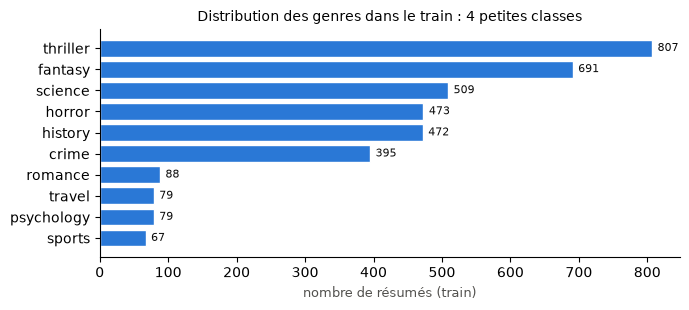

In [6]:
support = pd.DataFrame({name: {g: sum(g in t for t in df["labels"]) for g in ev.LABELS}
                        for name, df in splits.items()})
support["part (train)"] = support["train"] / support["train"].sum()
display(support.sort_values("train", ascending=False))

order = support.sort_values("train").index
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(order, support.loc[order, "train"], color=ev.SYSTEM_COLORS[0], edgecolor="white")
for y, value in enumerate(support.loc[order, "train"]):
    ax.text(value + 8, y, str(value), va="center", fontsize=8, color=ev.INK)
ax.set_xlabel("nombre de résumés (train)", fontsize=9, color=ev.INK_MUTED)
ax.set_title("Distribution des genres dans le train : 4 petites classes", fontsize=10)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

Le corpus est **déséquilibré** : thriller et fantasy dominent, tandis que psychology, romance,
sports et travel comptent chacun moins de 100 résumés d'entraînement et une douzaine en test.
Comme le F1 macro donne le même poids à chaque genre, ces 4 classes pèsent 40 % de la note
finale avec seulement ≈ 8 % des exemples de test.

## 7. Séparation train/validation/test

Découpage fait par Elyes (`notebooks/spliting.ipynb`) : `MultilabelStratifiedShuffleSplit`
(stratification multi-label itérative), d'abord 90 / 10 (test), puis 8/9 / 1/9 sur la partie
restante (validation), avec `random_state=67`. Rôles :

- **train** : apprentissage des modèles et écriture des règles ;
- **validation** : arrêt anticipé (DL), choix du checkpoint (Transformer), choix des seuils de
  décodage (section 14) ;
- **test** : évaluation finale uniquement.

In [7]:
sizes = pd.Series({name: len(df) for name, df in splits.items()})
shares = (support[["train", "validation", "test"]] / support[["train", "validation", "test"]].sum())
print("Tailles :", sizes.to_dict(), "| parts :", (sizes / sizes.sum()).round(3).to_dict())
print("Écart maximal de proportion d'un genre entre deux splits :",
      f"{(shares.max(axis=1) - shares.min(axis=1)).max():.3%}")

Tailles : {'train': 3580, 'validation': 447, 'test': 508} | parts : {'train': 0.789, 'validation': 0.099, 'test': 0.112}
Écart maximal de proportion d'un genre entre deux splits : 0.173%


## 8. Baseline (sans Machine Learning)

`src/baseline.py` (Clément) : lexique de 272 mots-clés écrits à la main, **forts** (poids 2,5)
ou **faibles** (poids 1), appariés par expressions régulières. Chaque mot-clé distinct compte une
fois. Décision : le genre de meilleur score (égalités départagées du genre le plus spécifique au
plus générique), plus tout genre dont le score atteint 0,9 × le meilleur. Si aucune règle ne se
déclenche, le genre par défaut est thriller. Aucun entraînement, aucune seed nécessaire.

In [8]:
val_pred_baseline = bl.predict(validation["text"])
delivered = pd.read_csv(ROOT / "results/baseline/validation_predictions.csv")["predicted_label"].map(ev.parse_labels)
print("Identique aux prédictions livrées :", all(list(a) == list(b) for a, b in zip(val_pred_baseline, delivered)))
print("Validation :", {k: round(v, 3) for k, v in ev.evaluate(validation["labels"], val_pred_baseline).items()})
print("\nExemple d'explication (test #236) :")
print(json.dumps(bl.explain(test["text"].iloc[236]), indent=1))

Identique aux prédictions livrées : True
Validation : {'accuracy': 0.452, 'precision_macro': 0.446, 'recall_macro': 0.638, 'f1_macro': 0.486, 'f1_micro': 0.505, 'n_examples': 447, 'n_empty_predictions': 0, 'n_multi_predictions': 57, 'labels_per_example': 1.174}

Exemple d'explication (test #236) :
{
 "prediction": [
  "crime"
 ],
 "top_scores": [
  [
   "crime",
   4.5
  ],
  [
   "history",
   1.0
  ],
  [
   "thriller",
   1.0
  ]
 ],
 "matched_keywords": {
  "crime": {
   "strong": [
    "murderer"
   ],
   "weak": [
    "investigation",
    "police"
   ]
  },
  "history": {
   "strong": [],
   "weak": [
    "soldier"
   ]
  },
  "thriller": {
   "strong": [],
   "weak": [
    "killer"
   ]
  }
 }
}


## 9. Deep Learning (PyTorch)

`src/deep_learning.py` (Faiki) : TF-IDF (unigrammes et bigrammes, 20 000 features, `min_df=2`,
stop words anglais), puis MLP `Linear(20000→256) → ReLU → Dropout(0,3) → Linear(256→10)`.
Loss `BCEWithLogitsLoss` pondérée (`pos_weight` = négatifs/positifs, contre le déséquilibre),
Adam (lr 1e-3, weight decay 1e-4), batch 64, au plus 20 époques, **arrêt anticipé sur le F1
macro de validation** (patience 4). Décodage : le genre le plus probable, plus tout genre de
probabilité ≥ 0,8.

In [9]:
dl_model = dl.load_model(ROOT / "results" / "deep_learning", device="cpu")
dl_val_probs = rev.dl_probabilities(dl_model, validation["text"])
print("Paramètres appris :", sum(p.numel() for p in dl_model.network.parameters()))
print("Validation (modèle livré) :",
      {k: round(v, 3) for k, v in ev.evaluate(validation["labels"], rev.dl_decode(dl_val_probs)).items()})

if RETRAIN_DL:
    retrained = dl.train(ROOT / "data/processed/train.csv", ROOT / "data/processed/validation.csv")
    same = rev.same_sets(rev.dl_decode(rev.dl_probabilities(retrained, test["text"])),
                         rev.dl_decode(rev.load_scores("deep_learning", "test")))
    print(f"\nRéentraînement seed 42 : prédictions de test identiques au modèle livré pour {same:.1%} des exemples")

Paramètres appris : 5122826
Validation (modèle livré) : {'accuracy': 0.7, 'precision_macro': 0.789, 'recall_macro': 0.678, 'f1_macro': 0.716, 'f1_micro': 0.717, 'n_examples': 447, 'n_empty_predictions': 0, 'n_multi_predictions': 2, 'labels_per_example': 1.004}


Device: mps
Representation: TF-IDF ngrams=(1, 2) max_features=20000
Architecture: Linear(20000) -> ReLU -> Dropout(0.3) -> Linear(10)
Loss: BCEWithLogitsLoss with pos_weight (class imbalance)
Optimizer: Adam lr=0.001 weight_decay=0.0001
Batch size: 64  Epochs: 20  Seed: 42
Decode: argmax + extra labels only if p >= 0.8
Train examples: 3580  Validation examples: 447
Vocabulary size: 20000

Training...


epoch 01  train_loss=1.2126  val_loss=1.1495  val_f1_macro=0.574  val_acc=0.640


epoch 02  train_loss=0.9755  val_loss=0.9228  val_f1_macro=0.655  val_acc=0.687


epoch 03  train_loss=0.6399  val_loss=0.7501  val_f1_macro=0.687  val_acc=0.700


...

epoch 07  train_loss=0.1843  val_loss=0.6923  val_f1_macro=0.716  val_acc=0.700


epoch 08  train_loss=0.1549  val_loss=0.7035  val_f1_macro=0.707  val_acc=0.700


epoch 09  train_loss=0.1355  val_loss=0.7048  val_f1_macro=0.705  val_acc=0.698


epoch 10  train_loss=0.1198  val_loss=0.7106  val_f1_macro=0.694  val_acc=0.687


epoch 11  train_loss=0.1083  val_loss=0.7294  val_f1_macro=0.704  val_acc=0.698
Early stopping at epoch 11 (best val F1 macro=0.716)

Training time: 2.98 s

Réentraînement seed 42 : prédictions de test identiques au modèle livré pour 100.0% des exemples


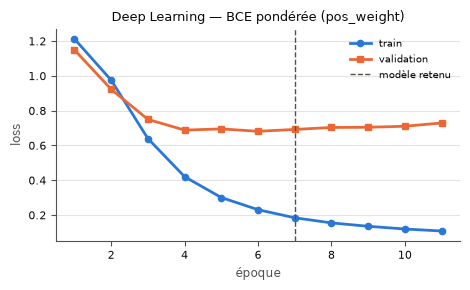

In [10]:
dl_config = json.load(open(ROOT / "results/deep_learning/config.json"))
curves = json.load(open(OUT / "courbes_loss.json"))
ev.plot_loss_curves({k: v for k, v in curves.items() if k.startswith("Deep")})
plt.show()

La loss de validation atteint son minimum vers l'époque 4-6 puis remonte doucement, pendant
que la loss d'entraînement continue de baisser : le modèle commence à sur-apprendre. L'arrêt
anticipé retient l'époque de meilleur F1 macro de validation (trait pointillé).

## 10. Transformer pré-entraîné

`src/transformer.py` (Nathan) : `distilbert-base-uncased` (66 M de paramètres, 6 couches),
version distillée de BERT, choisie parce qu'elle s'entraîne en quelques minutes sur un portable. Tokenizer
WordPiece du modèle, longueur maximale de 256 tokens (troncature). Tête de classification
linéaire à 10 sorties, `problem_type="multi_label_classification"` (sigmoïde + BCE). lr 2e-5,
batch 16, 5 époques, weight decay 0,01, bf16 sur MPS, meilleur checkpoint choisi sur le F1 macro
de validation. Décodage : chaque genre de probabilité ≥ 0,5, **indépendamment** (la prédiction
peut donc être vide).

In [11]:
tr_config = json.load(open(ROOT / "results/transformer/config.json"))
print({k: tr_config[k] for k in ["model_name", "max_length", "learning_rate", "batch_size", "epochs",
                                  "prediction_threshold", "device", "mixed_precision", "train_time_seconds"]})

if RETRAIN_TRANSFORMER:
    tr.train_transformer("data/processed/train.csv", "data/processed/validation.csv",
                         output_dir="results/transformer_retrain")

# Inférence du modèle livré sur 3 résumés de validation (démonstration).
tr_model, tokenizer = rev.load_transformer("cpu")
demo = validation.head(3)
probs = rev.transformer_probabilities(tr_model, tokenizer, demo["text"])
for text, truth, row in zip(demo["text"], demo["labels"], probs):
    print(f"vrai={truth}  prédit={ev.decode_independent(row[None])[0]}  top-3={an.fmt_probs(row)} | {text[:70]}…")

tr_val_probs = rev.load_scores("transformer", "validation")
print("\nValidation (modèle livré) :",
      {k: round(v, 3) for k, v in ev.evaluate(validation["labels"], ev.decode_independent(tr_val_probs)).items()})

{'model_name': 'distilbert-base-uncased', 'max_length': 256, 'learning_rate': 2e-05, 'batch_size': 16, 'epochs': 5, 'prediction_threshold': 0.5, 'device': 'mps', 'mixed_precision': 'bf16', 'train_time_seconds': 451.4922564159988}


vrai=['sports']  prédit=['sports']  top-3=sports 0.67, romance 0.12, thriller 0.08 | "Among the best books ever written on professional basketball." The Ph…
vrai=['history', 'science']  prédit=['history']  top-3=history 0.61, science 0.36, travel 0.08 | "Diamond has written a book of remarkable scope ... one of the most im…
vrai=['fantasy']  prédit=['fantasy']  top-3=fantasy 0.83, horror 0.13, romance 0.02 | "My name is MacKayla, Mac for short. I'm a sidhe-seer, one who sees th…

Validation (modèle livré) : {'accuracy': 0.655, 'precision_macro': 0.77, 'recall_macro': 0.592, 'f1_macro': 0.658, 'f1_micro': 0.722, 'n_examples': 447, 'n_empty_predictions': 65, 'n_multi_predictions': 3, 'labels_per_example': 0.861}


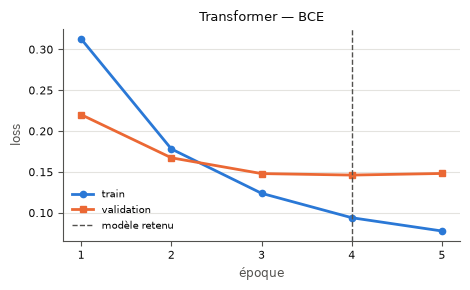

In [12]:
ev.plot_loss_curves({k: v for k, v in curves.items() if k.startswith("Transformer")})
plt.show()

Le meilleur checkpoint est celui de l'époque 4 (F1 macro de validation maximal). La loss de
validation se stabilise dès l'époque 3, alors que la loss d'entraînement continue de baisser.

## 11. Évaluation commune

`src/evaluation.py` applique **les mêmes fonctions** aux trois systèmes, à partir de leurs
prédictions sous forme de listes de genres :

- `evaluate(y_true, y_pred)` : accuracy (exact match), précision, rappel et F1 macro
  (`zero_division=0`), F1 micro, nombre de prédictions vides, nombre moyen de genres prédits ;
- `confusion_matrix(y_true, y_pred, scores)` : voir section 12 ;
- `time_inference(predict_fn, texts)` : mêmes 508 textes, préchauffage sur 32 textes, 3 passages
  chronométrés (médiane), batch de 32 pour les réseaux, de bout en bout (texte brut → genres).

Les scores de chaque système (scores de mots-clés, probabilités) ont été calculés une fois par
`src/run_evaluation.py` et sauvegardés dans `results/evaluation/scores/`. `src/analysis.py`
régénère ensuite, en une vingtaine de secondes, tous les tableaux et figures de `results/evaluation/`
(lancé en sous-processus, pour que les fichiers soient identiques à ceux produits en ligne de commande).

In [13]:
import subprocess

if RUN_SYSTEMS:
    subprocess.run([sys.executable, "src/run_evaluation.py", "--stage", "systems"], check=True,
                   capture_output=True)
subprocess.run([sys.executable, "src/analysis.py"], check=True, capture_output=True)
key = json.load(open(OUT / "key_numbers.json"))
print("Artefacts régénérés :", len(list(OUT.glob("*.*"))), "fichiers dans", OUT.relative_to(ROOT))

Artefacts régénérés : 41 fichiers dans results/evaluation


**Contrôle** : on recalcule les métriques de chaque `test_metrics.json` livré à partir de son `test_predictions.csv`.

In [14]:
rows = []
for system in ["baseline", "deep_learning", "transformer"]:
    delivered = pd.read_csv(ROOT / "results" / system / "test_predictions.csv")
    assert (delivered["text"].fillna("") == test["text"]).all()      # même test, même ordre
    mine = ev.evaluate(test["labels"], delivered["predicted_label"].map(ev.parse_labels))
    ref = json.load(open(ROOT / "results" / system / "test_metrics.json"))
    rows.append({"système": system, **{m: abs(mine[m] - ref[m]) for m in
                 ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_micro"]}})
print("Écart maximal avec les métriques livrées :", pd.DataFrame(rows).drop(columns="système").to_numpy().max())
display(pd.DataFrame(rows))

Écart maximal avec les métriques livrées : 0.0


,système,accuracy,precision_macro,recall_macro,f1_macro,f1_micro
0,baseline,0.0,0.0,0.0,0.0,0.0
1,deep_learning,0.0,0.0,0.0,0.0,0.0
2,transformer,0.0,0.0,0.0,0.0,0.0


### Tableau final (test, prédictions telles que livrées)

In [15]:
final_test = pd.read_csv(OUT / "tableau_final_test_lisible.csv")
display(final_test.head(3))
display(pd.read_csv(OUT / "metriques_detail_test.csv").head(3)[
    ["Méthode", "f1_micro", "n_empty_predictions", "n_multi_predictions", "labels_per_example"]])

,Méthode,Accuracy,Précision,Rappel,F1 macro,Train,Inférence
0,Baseline,0.415,0.426,0.613,0.464,0 s,1.15 ms/ex.
1,Deep Learning,0.701,0.764,0.707,0.730,2.9 s,0.12 ms/ex.
2,Transformer,0.650,0.754,0.584,0.654,451.5 s,10.27 ms/ex.


,Méthode,f1_micro,n_empty_predictions,n_multi_predictions,labels_per_example
0,Baseline,0.475,0,78,1.203
1,Deep Learning,0.711,0,5,1.010
2,Transformer,0.718,83,3,0.843


Train : baseline 0 s (le temps passé à écrire les règles n'est pas mesuré) ; DL : médiane de
nos 2 réentraînements (MPS) ; Transformer : temps enregistré par Nathan (MPS, bf16). Inférence :
CPU, mêmes conditions pour les trois systèmes.

In [16]:
display(pd.read_csv(OUT / "couts_temps.csv"))
timing = json.load(open(OUT / "timing.json"))
print(timing["machine"], "| threads torch :", timing["torch_threads"], "|", timing["protocol"])

,Méthode,Paramètres appris,Taille disque (Mo),Train (s),Inférence CPU (ms/ex.),Inférence MPS (ms/ex.),Test complet CPU (s)
0,Baseline,0,0.021,0.000,1.149,NaN,0.584
1,Deep Learning,5122826,22.092,2.949,0.121,0.147,0.061
2,Transformer,66961162,267.857,451.492,10.269,5.621,5.216


macOS-26.2-arm64-arm-64bit | threads torch : 8 | 508 test summaries, 1 warm-up call on 32 texts (not timed), 3 timed passes, median reported; end-to-end: raw text -> genres


### Même tableau sur la validation (pour mémoire : la validation a servi aux choix de chaque système)

In [17]:
display(pd.read_csv(OUT / "tableau_final_validation_lisible.csv").head(3))

,Méthode,Accuracy,Précision,Rappel,F1 macro,Train,Inférence
0,Baseline,0.452,0.446,0.638,0.486,0 s,1.15 ms/ex.
1,Deep Learning,0.700,0.789,0.678,0.716,2.9 s,0.12 ms/ex.
2,Transformer,0.655,0.770,0.592,0.658,451.5 s,10.27 ms/ex.


## 12. Matrices de confusion

Calculées sur les exemples de test à **un seul genre** (502 sur 508), avec une 11e colonne
« (aucun) » pour les prédictions vides. Si le vrai genre fait partie des genres prédits,
l'exemple compte comme juste (diagonale) ; sinon, on compte le **top-1** du système, calculé à
partir de ses scores (et non du premier genre de la liste, qui est alphabétique pour le DL).
Couleur : part de la ligne ; nombre : effectif.

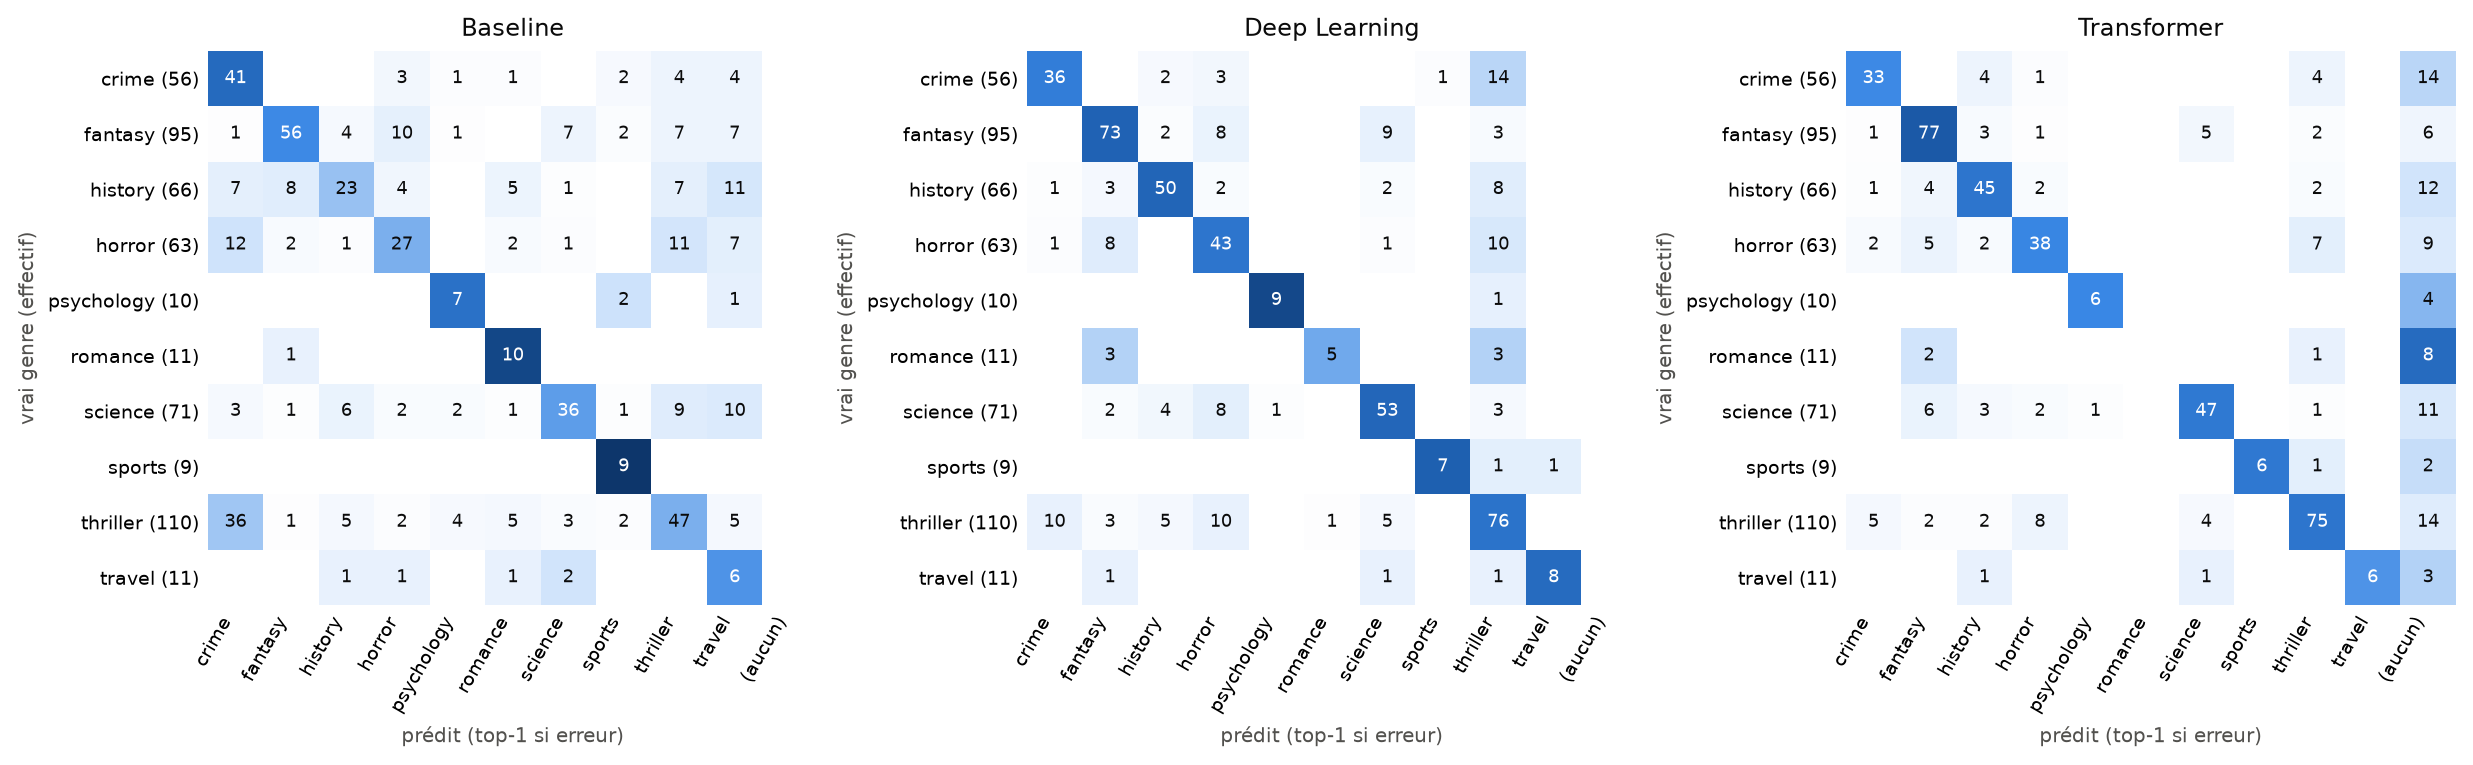

,crime,fantasy,history,horror,psychology,romance,science,sports,thriller,travel,(aucun)
vrai,,,,,,,,,,,
crime,36,0,2,3,0,0,0,1,14,0,0
fantasy,0,73,2,8,0,0,9,0,3,0,0
history,1,3,50,2,0,0,2,0,8,0,0
horror,1,8,0,43,0,0,1,0,10,0,0
psychology,0,0,0,0,9,0,0,0,1,0,0
romance,0,3,0,0,0,5,0,0,3,0,0
science,0,2,4,8,1,0,53,0,3,0,0
sports,0,0,0,0,0,0,0,7,1,1,0
thriller,10,3,5,10,0,1,5,0,76,0,0


In [18]:
display(Image(filename=OUT / "matrices_confusion.png"))
pd.read_csv(OUT / "confusion_deep_learning.csv", index_col=0)

Lecture :

- **Baseline** : beaucoup de thrillers classés crime (le vocabulaire de l'enquête est dans le
  lexique crime) et des genres « travel » ou « history » déclenchés par des mots isolés.
- **Deep Learning** : les erreurs se concentrent sur thriller, la classe majoritaire, qui absorbe
  crime et horror.
- **Transformer** : la colonne « (aucun) » est la plus remplie (83 prédictions vides) et romance
  n'est jamais prédite.

## 13. Analyse des erreurs

Sélection **reproductible** : 8 critères fixés à l'avance, puis un tirage aléatoire
(`default_rng(42)`) parmi les exemples de test qui vérifient chaque critère. Aucun exemple n'est
choisi à la main. Les hypothèses ont été écrites après lecture de chaque exemple.

In [19]:
display(Markdown((OUT / "erreurs.md").read_text(encoding="utf-8")))

# Analyse d'erreurs (test, prédictions telles que livrées)

Sélection automatique : pour chaque critère (ordre fixe), tirage aléatoire avec `numpy.random.default_rng(42)` parmi les exemples qui le vérifient, sans remise entre critères. Aucun exemple choisi à la main.

| Critère | Candidats | Retenus |
| --- | --- | --- |
| A. les trois systèmes se trompent | 88 | 2 |
| B. seule la baseline se trompe | 128 | 1 |
| C. le transformer ne prédit aucun genre | 83 | 1 |
| D. confusion thriller / crime / horror (DL ou transformer) | 61 | 1 |
| E. confusion fantasy / horror (DL ou transformer) | 18 | 1 |
| F. exemple à plusieurs genres | 6 | 1 |
| G. genre douteux : DL et transformer d'accord contre l'étiquette, tous deux à p >= 0.8 | 7 | 1 |
| H. petite classe manquée par le DL | 13 | 1 |

## Erreur 1 — test #38 (A. les trois systèmes se trompent)

> After four teenagers mysteriously die simultaneously in Tokyo, Kazuyuki Asakawa, a reporter and uncle to one of the deceased, decides to launch his own personal investigation. His search leads him to …

- Longueur : 274 mots
- **Vrai genre** : horror
- Baseline : crime — mots-clés : crime 2 (investigation, witnesses)
- Deep Learning : thriller — probabilités : thriller 0.37, crime 0.30, horror 0.22
- Transformer : (aucun) — probabilités : horror 0.49, thriller 0.47, crime 0.08
- Transformer, décodage harmonisé : horror, thriller
- **Hypothèse** : Résumé de *Ring* (K. Suzuki) écrit comme une enquête (reporter, « investigation », « witnesses ») : l'horreur n'est portée que par la cassette maudite, sans mot-clé explicite (ghost, haunted). La baseline tombe dans le piège lexical (crime). Le transformer place bien horror en tête (0,49) mais juste sous le seuil de 0,5 : il ne prédit rien.

## Erreur 2 — test #379 (A. les trois systèmes se trompent)

> The novel chronicles the stay of an unnamed weather official on a remote island in the south Atlantic close to the Antarctic Circle.

- Longueur : 23 mots
- **Vrai genre** : horror
- Baseline : travel — mots-clés : travel 1 (island)
- Deep Learning : thriller — probabilités : thriller 0.64, romance 0.25, travel 0.23
- Transformer : (aucun) — probabilités : science 0.18, thriller 0.16, horror 0.07
- Transformer, décodage harmonisé : science
- **Hypothèse** : Résumé de 23 mots sans aucun indice de genre (*La Peau froide*, roman d'horreur) : aucune méthode fondée sur le texte seul ne peut trouver horror. La baseline s'accroche à « island » (travel). Limite de la donnée, pas du modèle.

## Erreur 3 — test #236 (B. seule la baseline se trompe)

> March 1997. A woman has her throat cut behind a bar in Carter Crossing, Mississippi. Just down the road is a big army base. Is the murderer a local guy - or is he a soldier?  Jack Reacher, still a maj…

- Longueur : 145 mots
- **Vrai genre** : thriller
- Baseline : crime — mots-clés : crime 4.5 (murderer, investigation, police); history 1 (soldier); thriller 1 (killer)
- Deep Learning : thriller — probabilités : thriller 0.89, crime 0.20, horror 0.18
- Transformer : thriller — probabilités : thriller 0.94, romance 0.04, fantasy 0.03
- Transformer, décodage harmonisé : thriller
- **Hypothèse** : Piège lexical : le vocabulaire de l'enquête (murderer, investigation, police) donne 4,5 points à crime contre 1 à thriller (« killer », mot faible). Ce qui fait de ce livre un thriller (série Jack Reacher, action) n'est pas dans le lexique. Le DL et le transformer ont appris cette frontière sur les données et ont raison.

## Erreur 4 — test #219 (C. le transformer ne prédit aucun genre)

> Lane Roanoke is fifteen when she comes to live with her grandparents and fireball cousin at the Roanoke family's rural estate following the suicide of her mother. Over one long, hot summer, Lane exper…

- Longueur : 89 mots
- **Vrai genre** : thriller
- Baseline : romance, horror — mots-clés : horror 1 (darkness); romance 1 (heart)
- Deep Learning : romance — probabilités : romance 0.48, horror 0.48, fantasy 0.26
- Transformer : (aucun) — probabilités : horror 0.35, thriller 0.17, fantasy 0.14
- Transformer, décodage harmonisé : horror
- **Hypothèse** : Le suspense est suggéré (« terrible legacy », « either the girls run, or they die », « darkness ») mais jamais nommé. Les indices vont autant vers horror que vers romance : le DL hésite (0,48 / 0,48) et le transformer ne dépasse 0,5 pour aucun genre. Frontière floue entre thriller psychologique et horreur.

## Erreur 5 — test #436 (D. confusion thriller / crime / horror (DL ou transformer))

> The story takes place in 1960s suburban United States, and is told in flashback form by the narrator, David. After giving the reader a quick tour of his neighborhood and childhood friends, David intro…

- Longueur : 430 mots
- **Vrai genre** : thriller
- Baseline : travel — mots-clés : travel 3.5 (travel, tour); crime 2 (crime, police)
- Deep Learning : horror — probabilités : horror 0.39, history 0.22, science 0.19
- Transformer : horror — probabilités : horror 0.68, thriller 0.15, crime 0.04
- Transformer, décodage harmonisé : horror
- **Hypothèse** : *The Girl Next Door* (J. Ketchum) est souvent classé en horreur : la prédiction horror du DL et du transformer est défendable et l'étiquette thriller discutable. La baseline est piégée par « a quick tour of his neighborhood » et « travel » : le lexique ignore le contexte.

## Erreur 6 — test #116 (E. confusion fantasy / horror (DL ou transformer))

> Firmin, is a rat and the runt son of an alcoholic mother living in 1960s Boston, has been forced to survive on the pages of novels from the bookstore in which he dwells. At first everything holds the …

- Longueur : 57 mots
- **Vrai genre** : fantasy
- Baseline : thriller — mots-clés : aucun mot-clé, genre par défaut (thriller)
- Deep Learning : horror — probabilités : horror 0.40, science 0.33, fantasy 0.27
- Transformer : horror — probabilités : horror 0.64, thriller 0.09, fantasy 0.08
- Transformer, décodage harmonisé : horror
- **Hypothèse** : *Firmin* (S. Savage), fable littéraire sur un rat qui apprend à lire. Aucun mot du lexique : la baseline renvoie le genre par défaut. Le fantastique vient d'un animal qui lit, ce qui demande de comprendre le sens ; « rat », « alcoholic », « survive » tirent les deux réseaux vers horror. L'étiquette fantasy est elle-même discutable.

## Erreur 7 — test #481 (F. exemple à plusieurs genres)

> When fifteen-year-old Clary Fray heads out to the Pandemonium Club in New York City, she hardly expects to witness a murder― much less a murder committed by three teenagers covered with strange tattoo…

- Longueur : 171 mots
- **Vrai genre** : romance, fantasy
- Baseline : crime — mots-clés : crime 7 (murder, murderers, police, witness); fantasy 3 (demon, demons, warriors); horror 1 (blood)
- Deep Learning : fantasy — probabilités : fantasy 0.55, horror 0.43, romance 0.33
- Transformer : fantasy — probabilités : fantasy 0.75, horror 0.18, thriller 0.03
- Transformer, décodage harmonisé : fantasy
- **Hypothèse** : *City of Bones* (C. Clare), étiqueté romance + fantasy. Les deux réseaux trouvent fantasy mais pas romance, seulement suggérée par un personnage (« looks a little like an angel and acts a lot like a jerk »). La baseline est piégée par le vocabulaire du meurtre (crime 7 points). Les exemples multi-genres sont rares à l'entraînement : les modèles prédisent surtout un seul genre.

## Erreur 8 — test #136 (G. genre douteux : DL et transformer d'accord contre l'étiquette, tous deux à p >= 0.8)

> He was supposed to be a myth. But from the moment I crossed the River Styx and fell under his dark spell... he was, quite simply, mine.  Society darling Persephone Dimitriou plans to flee the ultra-mo…

- Longueur : 198 mots
- **Vrai genre** : romance
- Baseline : fantasy — mots-clés : fantasy 2.5 (spell); history 1 (war); thriller 1 (dangerous)
- Deep Learning : fantasy — probabilités : fantasy 0.85, romance 0.27, thriller 0.20
- Transformer : fantasy — probabilités : fantasy 0.94, romance 0.06, horror 0.04
- Transformer, décodage harmonisé : fantasy
- **Hypothèse** : *Neon Gods* (K. Robert), réécriture de Hadès et Perséphone : une romance dans un décor mythologique. Les trois systèmes prédisent fantasy, les réseaux avec confiance (0,85 et 0,94). L'étiquette unique romance est incomplète plutôt que fausse : romance + fantasy aurait été plus juste. Erreur de la donnée plus que du modèle.

## Erreur 9 — test #12 (H. petite classe manquée par le DL)

> A fresh, urban twist on the classic tale of star-crossed lovers.  When Brittany Ellis walks into chemistry class on the first day of senior year, she has no clue that her carefully created 'perfect' l…

- Longueur : 171 mots
- **Vrai genre** : romance
- Baseline : romance — mots-clés : romance 4.5 (passionate, boyfriend, chemistry); crime 1 (clue); thriller 1 (secret)
- Deep Learning : thriller — probabilités : thriller 0.59, romance 0.38, sports 0.26
- Transformer : (aucun) — probabilités : romance 0.38, thriller 0.29, sports 0.19
- Transformer, décodage harmonisé : romance, thriller
- **Hypothèse** : *Perfect Chemistry* (S. Elkeles) : la baseline a raison (passionate, boyfriend, chemistry). Le DL préfère thriller (gang, secret) ; le transformer place romance en tête (0,38) mais sous le seuil de 0,5. romance est une petite classe (88 résumés d'entraînement sur 3 580) : les réseaux y sont peu confiants.


## 14. Comparaison finale

### Analyse complémentaire : décodage harmonisé

Les trois systèmes ne transforment pas leurs scores en genres de la même façon (baseline : ratio
0,9 au meilleur score ; DL : top-1 + p ≥ 0,8 ; Transformer : p ≥ 0,5 par genre, prédiction
éventuellement vide). Pour séparer la qualité des scores de la règle de décision, on applique à
tous la même règle : **le genre le plus probable, plus les genres au-dessus d'un seuil**. Le seuil
est choisi **sur la validation** dans une grille fixée à l'avance, puis appliqué une seule fois
au test. Les lignes « telles que livrées » restent la référence.

In [20]:
grid = pd.read_csv(OUT / "decodage_grille_validation.csv")
display(grid.pivot(index="threshold", columns="système", values="f1_macro")
            .reindex(["0.2", "0.3", "0.4", "0.5", "0.6", "0.7", "0.8", "0.9", "top-1 seul"]))
print("Seuils livrés :", key["decoding_delivered"], "| choisis sur validation :", key["decoding_chosen_on_validation"])
display(final_test)

système,Baseline,Deep Learning,Transformer
threshold,,,
0.2,0.355,0.559,0.734
0.3,0.395,0.648,0.696
0.4,0.411,0.687,0.689
0.5,0.437,0.728,0.681
0.6,0.465,0.737,0.679
0.7,0.467,0.712,0.679
0.8,0.475,0.716,0.679
0.9,0.486,0.717,0.679
top-1 seul,0.487,0.717,0.679


Seuils livrés : {'baseline': 0.9, 'deep_learning': 0.8, 'transformer': 0.5} | choisis sur validation : {'baseline': 'top-1 seul', 'deep_learning': '0.6', 'transformer': '0.2'}


,Méthode,Accuracy,Précision,Rappel,F1 macro,Train,Inférence
0,Baseline,0.415,0.426,0.613,0.464,0 s,1.15 ms/ex.
1,Deep Learning,0.701,0.764,0.707,0.730,2.9 s,0.12 ms/ex.
2,Transformer,0.650,0.754,0.584,0.654,451.5 s,10.27 ms/ex.
3,"Baseline, décodage harmonisé (seuil top-1 seul)",0.455,0.452,0.559,0.449,0 s,1.15 ms/ex.
4,"Deep Learning, décodage harmonisé (seuil 0.6)",0.671,0.725,0.719,0.719,2.9 s,0.12 ms/ex.
5,"Transformer, décodage harmonisé (seuil 0.2)",0.583,0.697,0.783,0.732,451.5 s,10.27 ms/ex.


### Robustesse : intervalles de confiance (bootstrap, 1 000 tirages, seed 42) et test de McNemar

In [21]:
display(pd.read_csv(OUT / "bootstrap_f1_macro_test.csv"))
robust = json.load(open(OUT / "robustesse.json"))
pd.DataFrame({pair: {"écart F1 macro": v["f1_macro_difference"]["difference"],
                     "IC 95 % bas": v["f1_macro_difference"]["ci_low"],
                     "IC 95 % haut": v["f1_macro_difference"]["ci_high"],
                     "justes seulement pour A": v["mcnemar_exact_match"]["only_a_right"],
                     "justes seulement pour B": v["mcnemar_exact_match"]["only_b_right"],
                     "p McNemar (exact match)": v["mcnemar_exact_match"]["p_value_exact"]}
              for pair, v in robust["paired"].items()}).T

,Méthode,F1 macro,IC 95 % bas,IC 95 % haut
0,Baseline,0.464,0.414,0.507
1,Deep Learning,0.730,0.669,0.777
2,Transformer,0.654,0.596,0.696
3,"Baseline, décodage harmonisé (seuil top-1 seul)",0.449,0.395,0.495
4,"Deep Learning, décodage harmonisé (seuil 0.6)",0.719,0.657,0.766
5,"Transformer, décodage harmonisé (seuil 0.2)",0.732,0.678,0.773


,écart F1 macro,IC 95 % bas,IC 95 % haut,justes seulement pour A,justes seulement pour B,p McNemar (exact match)
deep_learning vs transformer,0.076,0.015,0.135,77.0,51.0,2.674e-02
deep_learning vs transformer_harmonise,-0.002,-0.060,0.057,108.0,48.0,1.748e-06
transformer_harmonise vs transformer,0.078,0.034,0.124,19.0,53.0,7.556e-05
deep_learning vs baseline,0.266,0.203,0.331,180.0,35.0,1.050e-24


### F1 par genre

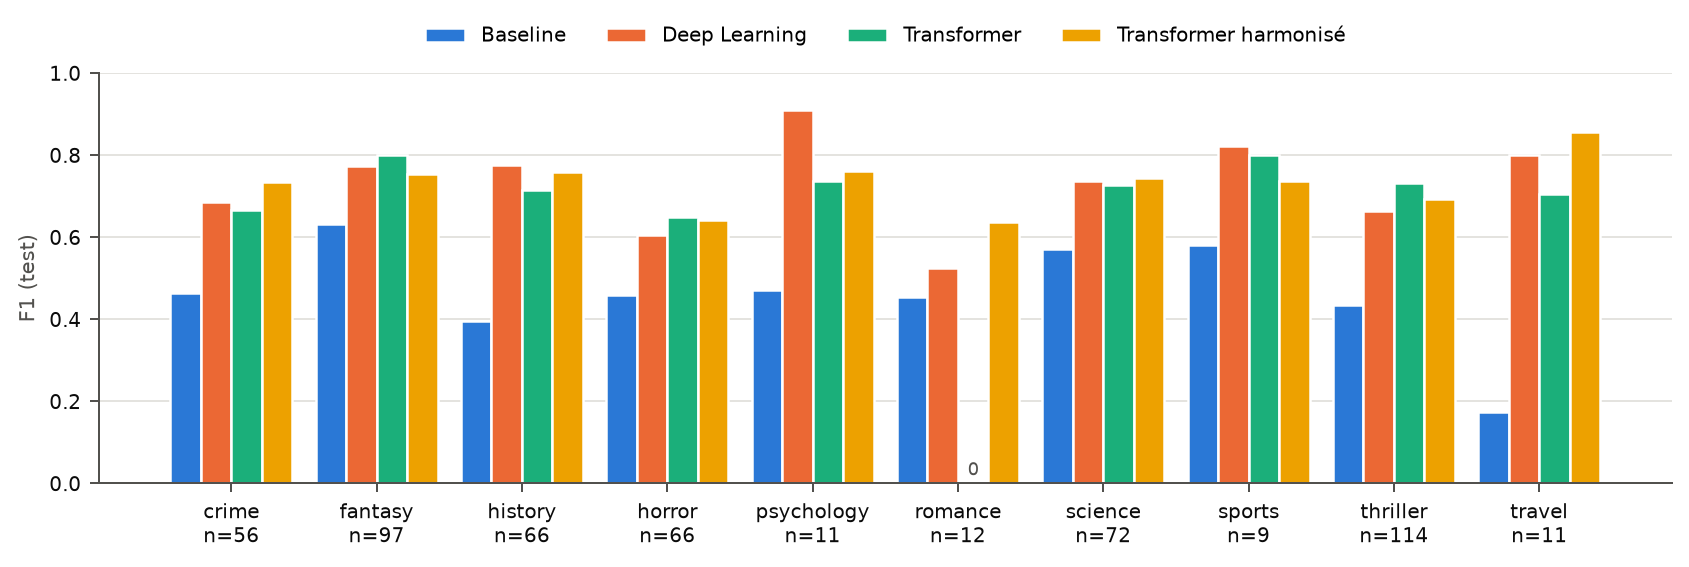

,genre,support,Baseline,Deep Learning,Transformer,"Baseline, décodage harmonisé (seuil top-1 seul)","Deep Learning, décodage harmonisé (seuil 0.6)","Transformer, décodage harmonisé (seuil 0.2)"
0,crime,56,0.463,0.686,0.667,0.494,0.691,0.734
1,fantasy,97,0.633,0.775,0.800,0.613,0.769,0.755
2,history,66,0.397,0.775,0.714,0.340,0.779,0.759
3,horror,66,0.460,0.606,0.650,0.444,0.621,0.642
4,psychology,11,0.471,0.909,0.737,0.452,0.870,0.762
5,romance,12,0.455,0.526,0.000,0.429,0.500,0.636
6,science,72,0.571,0.736,0.729,0.545,0.736,0.744
7,sports,9,0.581,0.824,0.800,0.600,0.824,0.737
8,thriller,114,0.436,0.664,0.733,0.400,0.669,0.694
9,travel,11,0.174,0.800,0.706,0.174,0.727,0.857


In [22]:
display(Image(filename=OUT / "f1_par_classe_test.png"))
pd.read_csv(OUT / "f1_par_classe_test.csv")

### Effet de l'artefact « (less) » sur le Transformer (seul système capable de le voir)

In [23]:
artifact = json.load(open(OUT / "artefact_less.json"))
pd.DataFrame({k: artifact[k] for k in ["transformer_delivered", "transformer_delivered_without_less",
                                       "transformer_harmonised", "transformer_harmonised_without_less"]}
             ).T[["accuracy", "precision_macro", "recall_macro", "f1_macro"]]

,accuracy,precision_macro,recall_macro,f1_macro
transformer_delivered,0.650,0.754,0.584,0.654
transformer_delivered_without_less,0.640,0.745,0.582,0.648
transformer_harmonised,0.583,0.697,0.783,0.732
transformer_harmonised_without_less,0.569,0.679,0.775,0.717


In [24]:
k = key
f1 = pd.read_csv(OUT / "tableau_final_test.csv").set_index("Méthode")["F1 macro"]
print(f"F1 macro test : baseline {f1['Baseline']:.3f} | DL {f1['Deep Learning']:.3f} | Transformer {f1['Transformer']:.3f}")
print(f"Transformer : {k['transformer_empty_test']} prédictions vides, dont {k['transformer_empty_test_argmax_right']} "
      f"où le genre le plus probable était le bon")
print("F1 moyen des 4 petites classes :", {n: round(v, 3) for n, v in k["f1_mean_small_classes"].items()})

F1 macro test : baseline 0.464 | DL 0.730 | Transformer 0.654
Transformer : 83 prédictions vides, dont 41 où le genre le plus probable était le bon
F1 moyen des 4 petites classes : {'Baseline': 0.42, 'Deep Learning': 0.765, 'Transformer': 0.561, 'Baseline, décodage harmonisé (seuil top-1 seul)': 0.414, 'Deep Learning, décodage harmonisé (seuil 0.6)': 0.73, 'Transformer, décodage harmonisé (seuil 0.2)': 0.748}


### Conclusion

**Système retenu : le Deep Learning (TF-IDF + MLP).**

- **Scores** : c'est le meilleur système tel que livré, en F1 macro comme en accuracy. Son
  avance sur le Transformer livré est significative (IC bootstrap de l'écart au-dessus de 0,
  McNemar p < 0,05).
- **Coût** : il s'entraîne en quelques secondes, prédit environ 85 fois plus vite que DistilBERT
  sur CPU et pèse 22 Mo contre 268 Mo.
- **Petites classes** : c'est lui qui les traite le mieux, grâce à la pondération `pos_weight`
  de sa loss.
- **Simplicité** : le pipeline est court et reproductible, et il n'a pas besoin de GPU.

**Nuances** :

- Avec un décodage qui garantit au moins un genre (seuil choisi sur la validation), le
  Transformer rejoint le DL en F1 macro. En revanche, il perd en exact match, et son seuil tient
  à une vingtaine d'exemples (romance, travel).
- Avec 9 à 12 exemples dans les petites classes, les écarts de quelques points ne sont pas
  significatifs.
- La baseline reste utile comme référence explicable (`explain()`), mais elle tombe dans les
  pièges lexicaux.

**Limites communes** :

- étiquettes parfois discutables et presque toujours uniques ;
- résumés très courts ou tronqués (48 % des résumés dépassent 256 tokens) ;
- artefact de collecte « (less) », qui dépend du genre.